Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from sklearn.model_selection import train_test_split

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import LSTM
from tensorflow.keras.layers import Embedding
from tensorflow.keras.layers import SimpleRNN
from tensorflow.keras.layers import Dropout
from tensorflow.keras.callbacks import EarlyStopping



# 1. Data Preparation

source:
- https://www.tensorflow.org/api_docs/python/tf/keras/utils/pad_sequences
- https://www.tensorflow.org/api_docs/python/tf/keras/preprocessing/text/Tokenizer



In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("clmentbisaillon/fake-and-real-news-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'fake-and-real-news-dataset' dataset.
Path to dataset files: /kaggle/input/fake-and-real-news-dataset


In [ ]:
fake_df = pd.read_csv(os.path.join(path, 'Fake.csv'))
true_df = pd.read_csv(os.path.join(path, 'True.csv'))

In [ ]:
# I need to add labels now
# The reason that I'm labeling them is because I will combine them
# into one full dataframe where the models will be able to learn
# what true news is label = 1 and
# what fake news is label = 0

# true => label = 1
# fake => label = 0
fake_df["label"] = 0
true_df["label"] = 1

In [ ]:
fake_df.head()

,title,text,subject,date,label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",0
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",0
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",0
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",0
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",0


In [ ]:
true_df.head()

,title,text,subject,date,label
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017",1
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017",1
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017",1
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017",1
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017",1


In [ ]:
# now let us combine them
full_df = pd.concat([fake_df, true_df], ignore_index=True)

In [ ]:
full_df.head()

,title,text,subject,date,label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",0
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",0
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",0
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",0
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",0


In [ ]:
# Now I need to shuffle it because as you can see
# They are in ordered based on labels
# This will create bias
full_df = full_df.sample(frac=1).reset_index(drop=True)

In [ ]:
full_df.head()

,title,text,subject,date,label
0,White House aims to be forthright in Congress ...,WASHINGTON (Reuters) - The Trump administratio...,politicsNews,"March 30, 2017",1
1,PRESIDENT TRUMP’S REMARKS at Ford’s Theatre Ga...,PRESIDENT TRUMP and FIRST LADY MELANIA TRUMP a...,politics,"Jun 4, 2017",0
2,BLACK LIVES MATTER TERRORISTS Take To Social M...,There are no words for these selfish sub-human...,politics,"Jul 15, 2016",0
3,White House budget chief says any tax package ...,WASHINGTON (Reuters) - White House budget chie...,politicsNews,"September 7, 2017",1
4,AWESOME PRO-GUN AD Removed From Airport After ...,The rainbows and unicorn crowd decided they ju...,left-news,"Jul 9, 2016",0


In [ ]:
full_df.shape

(44898, 5)

In [ ]:
full_df.columns

Index(['title', 'text', 'subject', 'date', 'label'], dtype='object')

In [ ]:
# check for missing values
print(full_df.isnull().sum())

title      0
text       0
subject    0
date       0
label      0
dtype: int64


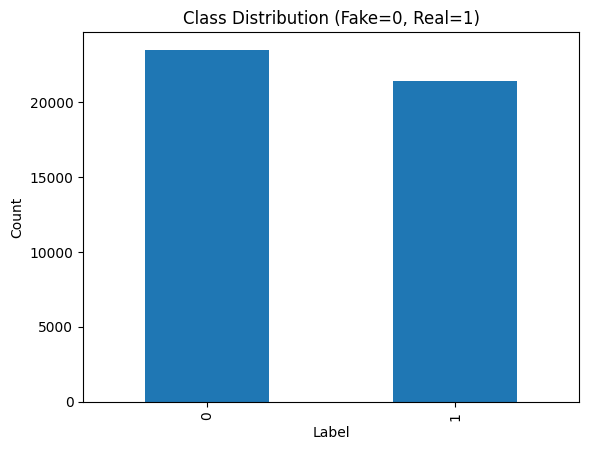

label
0    23481
1    21417
Name: count, dtype: int64


In [ ]:
# class distribution plot
full_df["label"].value_counts().plot(kind="bar")
plt.title("Class Distribution (Fake=0, Real=1)")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()

print(full_df["label"].value_counts())

It is a reasonably balanced dataset.
it alsmost approximately 52% fake, and 48% true.

In [ ]:
# So, now let us combine "Title" and "Text" columns into a single "content" column
# I will be doing this because:
# The title is a summary of the article
# and the body is the main text with the details
# so we need both in the same column so that the model can learn from both
full_df["content"] = full_df["title"] + " " + full_df["text"]

In [ ]:
# Let us clean the text and remove symbols

def clean_text(text):
    text = text.lower()
    text = text.replace(".", "")
    text = text.replace(",", "")
    text = text.replace("!", "")
    text = text.replace("?", "")
    return text

full_df["content"] = full_df["content"].apply(clean_text)

In [ ]:
# train/test/split validation

X = full_df["content"]
y = full_df["label"]

# split the full dataset into 80% training and the remaining 20% will
# then be split into 10% test and 10% validation sets respectively
# random_state = 42, a seed for random generation
# stratify = y to ensure the class distribution is preserved.
X_train, X_remaining, y_train, y_remaining = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Now the second split for test and valdation using the remaining 20%
X_val, X_test, y_val, y_test = train_test_split(
    X_remaining, y_remaining, test_size=0.5, random_state=42, stratify=y_remaining
)



Since, model like RNN and LSTM only understand number but not text, so we need to tokenize the text. Tokenization is a process where the text is converted into numbers. This way the models can understand what is going on.

In [ ]:
# Tokenization here
# Here I will be using Keras Tokenizer class
# I will provide an argumnet num_words = MAX_WORDS that caps the size of the vocabulary.

# 20,000 because I will try to include as much information as possible
# including rare words, typos, names, and so on
MAX_WORDS = 20000
MAX_LENGTH = 300

# tokenize with a limit of max_words
tokenizer = Tokenizer(num_words=MAX_WORDS)
# fit and map each word to a unique integer index
tokenizer.fit_on_texts(X_train)

# Now convert text into sequences of numbers using the vocabulary dictionary we tokenized above
X_train_sequence = tokenizer.texts_to_sequences(X_train)
X_val_sequence = tokenizer.texts_to_sequences(X_val)
X_test_sequence = tokenizer.texts_to_sequences(X_test)


In [ ]:
# Padding here
# This function transforms a list (of length num_samples) of sequences (lists of integers) into a
# 2D NumPy array of shape (num_samples, num_timesteps).
# num_timesteps is either the maxlen argument if provided,
# or the length of the longest sequence in the list.
X_train_padded = pad_sequences(X_train_sequence, maxlen=MAX_LENGTH)
X_val_padded = pad_sequences(X_val_sequence, maxlen=MAX_LENGTH)
X_test_padded = pad_sequences(X_test_sequence, maxlen=MAX_LENGTH)

# 2. RNN Model

source:
- https://keras.io/api/callbacks/early_stopping/
- https://www.geeksforgeeks.org/deep-learning/binary-cross-entropy-log-loss-for-binary-classification/

In [ ]:
EPOCHS = 50
BATCH_SIZE = 32

In [ ]:
rnn_model = Sequential()

# Embedding will take as input an integer matrix of size batch and input size
# input_dim is the size of vocabulary i.e max integer index +1
rnn_model.add(Embedding(input_dim=MAX_WORDS, input_length=MAX_LENGTH, output_dim=128))

rnn_model.add(SimpleRNN(64))

# I will be using a dropout and early stopping as well.
# Dropout randomly turnsoff some neurons so that they dont depend on the training data
# they will learn more patterns instead
rnn_model.add(Dropout(0.3))

# since the output is binary
# > 0.5 => Real (1)
# < 0.5 => Fake (0)
# I will be using sigmoid activation for binary classification and
# binary_crossentropy for the same reason
rnn_model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [ ]:
# compile the model
# binary cross entropy quantifies the difference between the actual class labels
# (0 or 1) and the predicted probabilities output by the model
rnn_model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [ ]:
early_stop = EarlyStopping(
  monitor='val_loss', # quantity to be monitored
  patience = 4,   # number of epoch with no improvemnet after which training will be stopped
  restore_best_weights = True # restores the best model weight during training instead of the final epoch
)

In [ ]:
rnn_history = rnn_model.fit(
  X_train_padded, y_train,
  epochs= EPOCHS,
  batch_size = BATCH_SIZE,
  validation_data = (X_val_padded, y_val),
  callbacks=[early_stop]
)

Epoch 1/50
1123/1123 ━━━━━━━━━━━━━━━━━━━━ 33s 25ms/step - accuracy: 0.9239 - loss: 0.1967 - val_accuracy: 0.9722 - val_loss: 0.0879
Epoch 2/50
1123/1123 ━━━━━━━━━━━━━━━━━━━━ 27s 24ms/step - accuracy: 0.9781 - loss: 0.0662 - val_accuracy: 0.9708 - val_loss: 0.0898
Epoch 3/50
1123/1123 ━━━━━━━━━━━━━━━━━━━━ 43s 26ms/step - accuracy: 0.9703 - loss: 0.0852 - val_accuracy: 0.9212 - val_loss: 0.2042
Epoch 4/50
1123/1123 ━━━━━━━━━━━━━━━━━━━━ 37s 23ms/step - accuracy: 0.9813 - loss: 0.0516 - val_accuracy: 0.9682 - val_loss: 0.1144
Epoch 5/50
1123/1123 ━━━━━━━━━━━━━━━━━━━━ 25s 22ms/step - accuracy: 0.9912 - loss: 0.0285 - val_accuracy: 0.9713 - val_loss: 0.0953


In [ ]:
# extract RNN history
rnn_train_loss = rnn_history.history['loss']
rnn_val_loss   = rnn_history.history['val_loss']
rnn_train_acc  = rnn_history.history['accuracy']
rnn_val_acc    = rnn_history.history['val_accuracy']

In [ ]:
def plot_history(train_loss, val_loss, train_acc, val_acc, model_name):
  # loss curve first
  plt.figure(figsize=(10, 5))
  plt.plot(train_loss, label='Train Loss', marker='o')
  plt.plot(val_loss,   label='Val Loss',   marker='o')
  plt.title(f'{model_name} - Training vs Validation Loss')
  plt.xlabel('Epoch')
  plt.ylabel('Loss')
  plt.legend()
  plt.grid(True)
  plt.show()
  # Accuracy curve
  plt.figure(figsize=(10, 5))
  plt.plot(train_acc, label='Train Accuracy', marker='o')
  plt.plot(val_acc,   label='Val Accuracy',   marker='o')
  plt.title(f'{model_name} - Training vs Validation Accuracy')
  plt.xlabel('Epoch')
  plt.ylabel('Accuracy')
  plt.legend()
  plt.grid(True)
  plt.show()

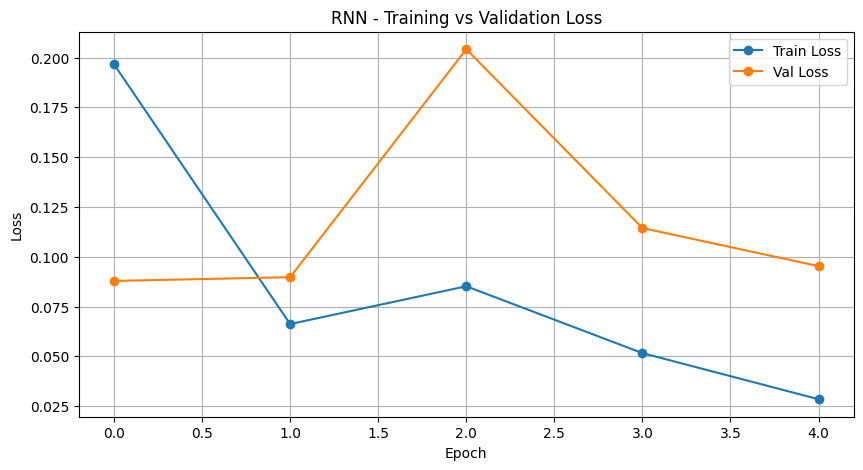

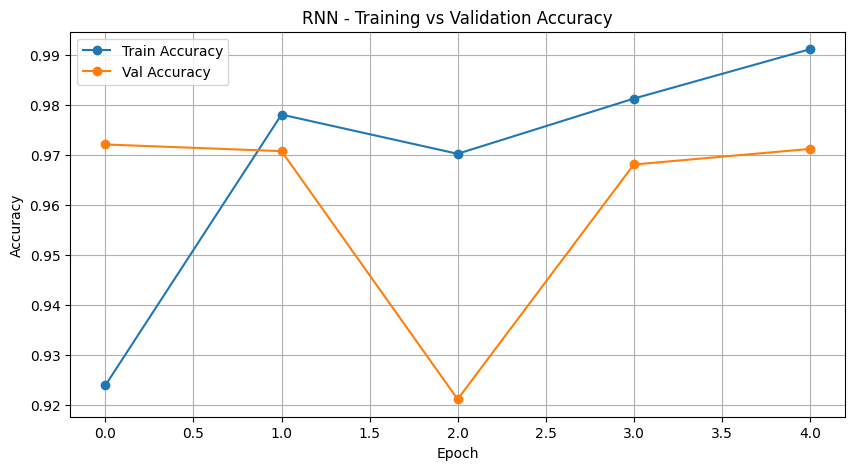

In [ ]:
plot_history(rnn_train_loss, rnn_val_loss, rnn_train_acc, rnn_val_acc, 'RNN')

- The loss curve shows a spike at epoch 2 for validation . the loss jumped from 0.090 to 0.200, then dipped again to stop learning at around 0.092. This explain that the model stuggled a little bit before early stopping at epoch 4. The training loss starts at 0.200 then kept decreasing upto epoch 1, then kept decreasing.
- When looking at the accuracy plot, thre was a difference between validation and training accuracy until epoch 3 but they final picked up and increased. The model did very well on training data and generalized well with the unseen datat but it can be seen that there is a mild overfitting.


# 3. LSTM Model

In [ ]:
lstm_model = Sequential()

lstm_model.add(Embedding(input_dim=MAX_WORDS, input_length=MAX_LENGTH, output_dim=128))

lstm_model.add(LSTM(64))

# same dropout value
lstm_model.add(Dropout(0.3))

lstm_model.add(Dense(1, activation='sigmoid'))

In [ ]:
# compile the lstm model
lstm_model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [ ]:
lstm_history = lstm_model.fit(
    X_train_padded, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val_padded, y_val),
    callbacks=[early_stop]
)

Epoch 1/50
1123/1123 ━━━━━━━━━━━━━━━━━━━━ 23s 15ms/step - accuracy: 0.9636 - loss: 0.1066 - val_accuracy: 0.9708 - val_loss: 0.0993
Epoch 2/50
1123/1123 ━━━━━━━━━━━━━━━━━━━━ 18s 16ms/step - accuracy: 0.9872 - loss: 0.0410 - val_accuracy: 0.9884 - val_loss: 0.0440
Epoch 3/50
1123/1123 ━━━━━━━━━━━━━━━━━━━━ 17s 15ms/step - accuracy: 0.9930 - loss: 0.0248 - val_accuracy: 0.9570 - val_loss: 0.1286
Epoch 4/50
1123/1123 ━━━━━━━━━━━━━━━━━━━━ 17s 15ms/step - accuracy: 0.9913 - loss: 0.0273 - val_accuracy: 0.9802 - val_loss: 0.0729
Epoch 5/50
1123/1123 ━━━━━━━━━━━━━━━━━━━━ 18s 16ms/step - accuracy: 0.9982 - loss: 0.0058 - val_accuracy: 0.9924 - val_loss: 0.0340
Epoch 6/50
1123/1123 ━━━━━━━━━━━━━━━━━━━━ 17s 15ms/step - accuracy: 0.9987 - loss: 0.0043 - val_accuracy: 0.9920 - val_loss: 0.0322
Epoch 7/50
1123/1123 ━━━━━━━━━━━━━━━━━━━━ 19s 17ms/step - accuracy: 0.9976 - loss: 0.0073 - val_accuracy: 0.9922 - val_loss: 0.0313
Epoch 8/50
1123/1123 ━━━━━━━━━━━━━━━━━━━━ 17s 15ms/step - accuracy: 1.0000 -

In [ ]:
#extract LSTM history
lstm_train_loss = lstm_history.history['loss']
lstm_val_loss   = lstm_history.history['val_loss']
lstm_train_acc  = lstm_history.history['accuracy']
lstm_val_acc    = lstm_history.history['val_accuracy']

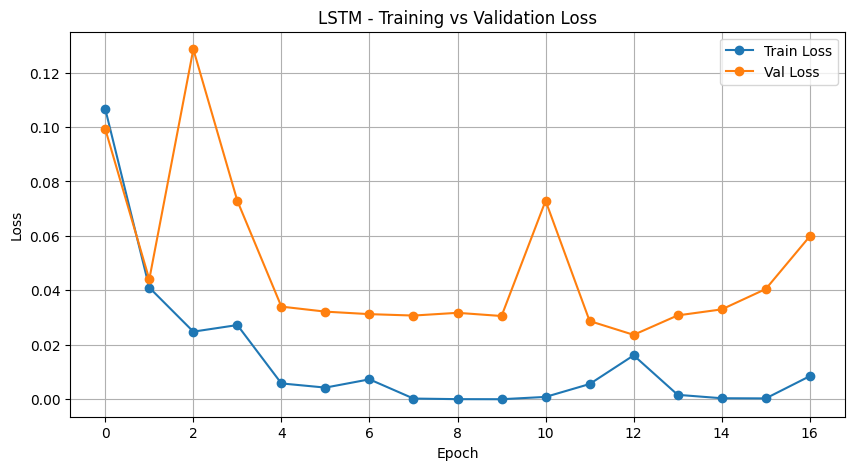

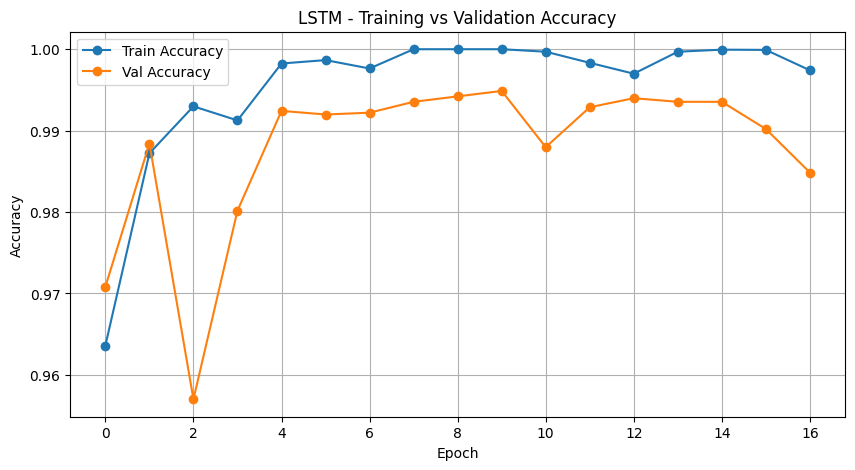

In [ ]:
plot_history(lstm_train_loss, lstm_val_loss, lstm_train_acc, lstm_val_acc, 'LSTM')

- Both of loss for validation and validation started hugh and then decreased. At epoch 2 the validation loss hit a spike loss that is over 0.12. At this point the validation loss kept decreasing.The differecnce in the loss shows mild overfitting.
- When looking at the accuracy plot: training accuracy reaches 100% at around epoch 7 and stayed there until epoch 10 decreases then got back up and finally drops a little bit. Validation accuracy on the other hand though peaked at around epoch 9 and finished offaround 98.50% when it was early stopped at epoch 16.
- LSTM took more epoch to converge comapred to RNN

# 4. Transformer Model (TinyBERT)



Source:
- https://huggingface.co/huawei-noah/TinyBERT_General_4L_312D
- https://arxiv.org/abs/1909.10351
- https://huggingface.co/docs/transformers/v4.18.0/en/training
- https://github.com/huawei-noah/Pretrained-Language-Model/blob/master/TinyBERT/transformer/modeling.py
- https://huggingface.co/docs/transformers/v4.18.0/en/training#metrics
- https://huggingface.co/docs/transformers/model_doc/auto#transformers.AutoModelForSequenceClassification

- TinyBERT was chosen as a trasnformer-based model due to its distilled version of BERT model with 4 layers and 14 million parameters which makes it astronger model then RNN and LSTM.
- It also fits the project's compute constraints to represent a transformer-based architecture.
- In this comparison, TinyBERT is expected to out perform the other models because as a transformer based model it is already pretrained on large text data and has a core understanding of context better than RNN and LSTM since they are trained from scratch.

- TinyBERT is a distilled version of BERT developed by Huawei Noah's Ark Lab (Jiao et al., 2019). BERT's main idea is that by randomly masking some tokens, the model can train on text to the left and right, giving it a more thorough understanding.  TinyBERT is also very versatile because its learned language representations can be adapted for other NLP tasks by fine-tuning an additional layer or head.


In [ ]:
!  pip install transformers -q

In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from transformers import TrainingArguments, Trainer
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from torch.utils.data import Dataset
import torch

# loads the correct tokenizer suitable for BERT
tiny_bert_tokenizer = AutoTokenizer.from_pretrained("huawei-noah/TinyBERT_General_4L_312D")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/409 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

In [ ]:
# in the documentation exmpale it used example text sentence amd paddding of max length with truncation True
# Here we need to modify an dmake changes for the tokenize_fuction to fit our purpose
# It converts raw text into input_ids and attention_mask
# input_ids are indices of input sequence tokens in the vocabulary.
# they are pretty much the number of tokens that BERT actually reads
# -----------------
# attention_mask is aMask to avoid performing attention on padding token indices. Mask values selected in [0, 1]:
# 1 for tokens that are not masked,
# 0 for tokens that are masked.
# it explains which tokens are real and which ones are mask for the BERT model
def tokenize_function(texts):
  return tiny_bert_tokenizer(texts, padding="max_length", truncation=True, max_length=300)

In [ ]:
# dataset prep
# BERT tokenizer will expect list of strings
X_train_BERT_sequence = tokenize_function(X_train.tolist())
X_val_BERT_sequence = tokenize_function(X_val.tolist())
X_test_BERT_sequence  = tokenize_function(X_test.tolist())

For TinyBERT, I will be using "The Trainer API". The transformer library provide a Trainer API that allows you to easily fine-tune transformer models on you rown dataset. The trainer class takes your datasets, you rmodel as well as the training hyperparameters and can perform the training on any kind of setup (CPU, GPU, muti GPUs, TPUs). It can also compute the predictions on any dataset, and if you provided metrics, evaluate your model on any dataset. It can also handle final data-processing such as dynamic padding as long as you provide the tokenizer or a given data collator.

The TinyBERT model doesn't just take a PandaSeries data. BERT model takes in it's own input parameters. It expects (input_ids),(attention_mask)and (labels => fake = 0 and true = 1) as an input parameter during its forward pass. These two inputs come directly from the tokenizer (bert_tokenizer) we defined earlier.

The process goes as follows:

Tokenizer creates(input_ids and attention_mask) then the X_train_BERT_sequence will have them as a package then the trainer feeds them into BERT.

In [ ]:
from datasets import Dataset

# I need to convert them directly into Huggingace Dataset to be able to use Trainer API
train_dataset = Dataset.from_dict({
    'input_ids':      X_train_BERT_sequence['input_ids'],
    'attention_mask': X_train_BERT_sequence['attention_mask'],
    'labels':         y_train.tolist()
})

val_dataset = Dataset.from_dict({
    'input_ids':      X_val_BERT_sequence['input_ids'],
    'attention_mask': X_val_BERT_sequence['attention_mask'],
    'labels':         y_val.tolist()
})

test_dataset = Dataset.from_dict({
    'input_ids':      X_test_BERT_sequence['input_ids'],
    'attention_mask': X_test_BERT_sequence['attention_mask'],
    'labels':         y_test.tolist()
})

# Tell HuggingFace to use PyTorch tensors
train_dataset.set_format("torch")
val_dataset.set_format("torch")
test_dataset.set_format("torch")

- Now let us load the pretrained TinyBERT model. Here I will be using a transformers class called AutoModelForSequenceClassification which is  will be instantiated as one of the model classes of the library (with a sequence classification head) and it will have a from_pretrained class method within that will load the pretrained BERT weights from HuggingFace.


In [ ]:
tiny_bert_model = AutoModelForSequenceClassification.from_pretrained(
    "huawei-noah/TinyBERT_General_4L_312D",
    num_labels=2, # defines the amount of labels in the dataset as abinary classification
    hidden_dropout_prob = 0.3,
    attention_probs_dropout_prob = 0.3 # dropout the same as RNN and LSTM
)

pytorch_model.bin:   0%|          | 0.00/62.7M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/71 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: huawei-noah/TinyBERT_General_4L_312D
Key                                        | Status     | 
-------------------------------------------+------------+-
fit_denses.{0, 1, 2, 3, 4}.weight          | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
fit_denses.{0, 1, 2, 3, 4}.bias            | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not o

- With RNN and LSTM, the models converged and model trianing was stopped 6 and 9 epoch in respectively. In TinyBERT the recommended epoch size is 3-5 because it is fine-tuning as it already has a strong language understanding due to its pretraining that it had. So I will be using only 3 peochs.
- It also needs smaller batches because it is a heavier model. So I will be using atch size = 16 per epochs

In [ ]:
training_args = TrainingArguments(
  output_dir="test_trainer",
  eval_strategy="epoch",
  save_strategy="epoch",
  num_train_epochs= 3,
  per_device_train_batch_size=16,
  load_best_model_at_end=True
)

In [ ]:
def compute_metrics(eval_pred):
  logits, labels = eval_pred
  predictions = np.argmax(logits, axis= -1)
  precision, recall, f1, _ = precision_recall_fscore_support(
      labels, predictions, average='binary')

  tiny_bert_accuracy = accuracy_score(labels, predictions)

  return{
    'accuracy' : tiny_bert_accuracy,
    'precision': precision,
    'recall'   : recall,
    'f1'       : f1
  }


In [ ]:
from transformers import EarlyStoppingCallback

trainer = Trainer(
    model=tiny_bert_model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=4)]  # same patience as RNN and LSTM
)

In [ ]:
bert_history = trainer.train()

model.safetensors:   0%|          | 0.00/62.7M [00:00<?, ?B/s]

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.008090,0.008472,0.998886,0.999066,0.998599,0.998833
2,0.001891,0.006204,0.999332,0.999533,0.999066,0.999300
3,0.001519,0.004830,0.999555,1.000000,0.999066,0.999533


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias'].
There were unexpected keys in the checkp

# Training and Validation loss curves

In [ ]:
# Extract TinyBERT History
tiny_bert_logs       = [x for x in trainer.state.log_history if 'eval_loss' in x]
tiny_bert_train_logs = [x for x in trainer.state.log_history if 'loss' in x and 'eval_loss' not in x]

tiny_bert_train_loss = [x['loss'] for x in tiny_bert_train_logs]
tiny_bert_val_loss   = [x['eval_loss'] for x in tiny_bert_logs]
tiny_bert_val_acc    = [x['eval_accuracy'] for x in tiny_bert_logs]

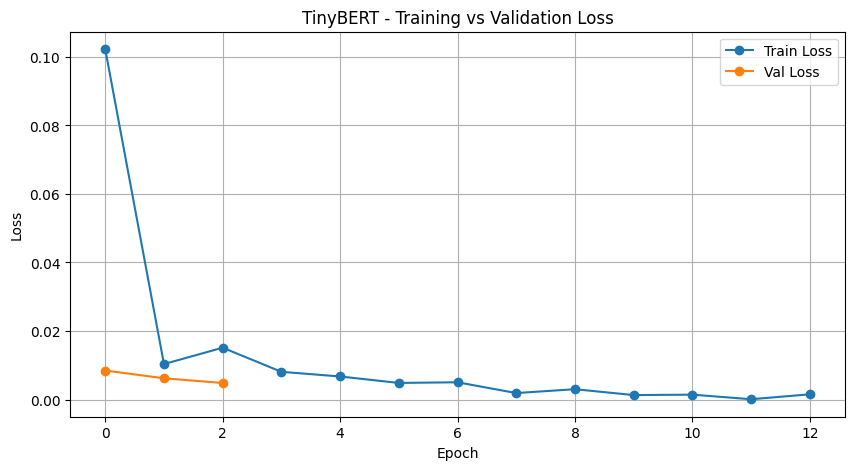

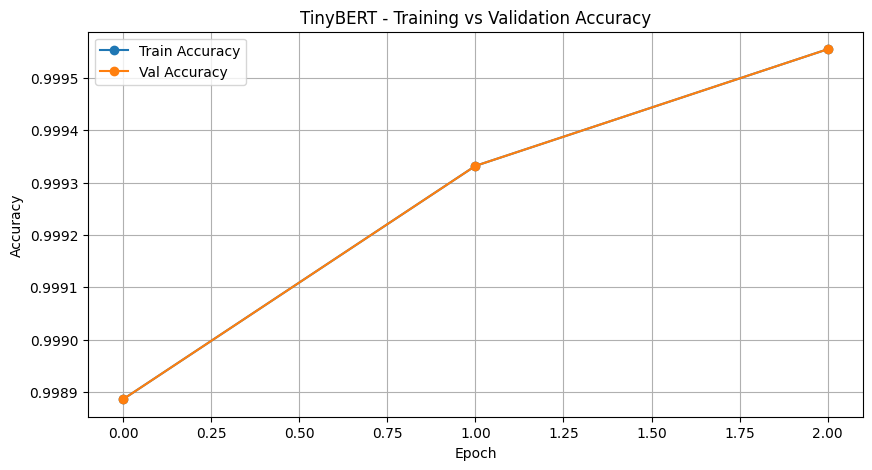

In [ ]:
# TinyBERT — val accuracy only since train accuracy is not available
plot_history(tiny_bert_train_loss, tiny_bert_val_loss, tiny_bert_val_acc, tiny_bert_val_acc, 'TinyBERT')

- TinyBERT is the most stable version compared to the others. It converged faster. When looking at the loss plots, the validation got to 0 ealier than the training. Due to its pre training, it understood languages so it didn't waste any time learning the language. Due to that reason, it spent most of the job just trying to differentiate between fake news and true news unlike RNN & LSTM, where they learned to understand the language and then differntiate the labels.
- And aslo it only has validation accuracy, this is because of hugging face's trainer API, that it doesn't log training accuracy by default. So when looking at the validation accuracy it just increased through the epochs from 99.89 to 99.95, showing that TinyBERT is indeed a strong model for fake news detection.

# 5. Comparison & Insights

In [ ]:
print(rnn_history.history['loss'][-1])      # final train loss
print(rnn_history.history['val_loss'][-1])  # final val loss

0.028485387563705444
0.09530965238809586


In [ ]:
print(lstm_history.history['loss'][-1])
print(lstm_history.history['val_loss'][-1])

0.008488725870847702
0.05984612554311752


In [ ]:
print(f"TinyBERT Train Loss: {tiny_bert_train_loss[-1]:.4f}")
print(f"TinyBERT Val Loss:   {tiny_bert_val_loss[-1]:.4f}")

TinyBERT Train Loss: 0.0015
TinyBERT Val Loss:   0.0048


# Test set performance

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

#  RNN Test Evaluation
rnn_preds = (rnn_model.predict(X_test_padded) > 0.5).astype(int)
print("RNN Test Results:")
print(f"Accuracy:  {accuracy_score(y_test, rnn_preds):.4f}")
print(f"Precision: {precision_score(y_test, rnn_preds):.4f}")
print(f"Recall:    {recall_score(y_test, rnn_preds):.4f}")
print(f"F1:        {f1_score(y_test, rnn_preds):.4f}")

# LSTM Test Evaluation
lstm_preds = (lstm_model.predict(X_test_padded) > 0.5).astype(int)
print("\nLSTM Test Results:")
print(f"Accuracy:  {accuracy_score(y_test, lstm_preds):.4f}")
print(f"Precision: {precision_score(y_test, lstm_preds):.4f}")
print(f"Recall:    {recall_score(y_test, lstm_preds):.4f}")
print(f"F1:        {f1_score(y_test, lstm_preds):.4f}")

# TinyBERT Test Evaluation
tiny_bert_predictions = trainer.predict(test_dataset)
tiny_bert_preds = np.argmax(tiny_bert_predictions.predictions, axis=-1)
print("\nTinyBERT Test Results:")
print(f"Accuracy:  {accuracy_score(y_test, tiny_bert_preds):.4f}")
print(f"Precision: {precision_score(y_test, tiny_bert_preds):.4f}")
print(f"Recall:    {recall_score(y_test, tiny_bert_preds):.4f}")
print(f"F1:        {f1_score(y_test, tiny_bert_preds):.4f}")

141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step
RNN Test Results:
Accuracy:  0.9673
Precision: 0.9557
Recall:    0.9767
F1:        0.9661
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step

LSTM Test Results:
Accuracy:  0.9909
Precision: 0.9925
Recall:    0.9883
F1:        0.9904



TinyBERT Test Results:
Accuracy:  0.9993
Precision: 0.9991
Recall:    0.9995
F1:        0.9993


| Model | Train Loss | Val Loss | Test Accuracy | Test Precision | Test Recall | Test F1 | Parameters |
|---|---|---|---|---|---|---|---|
| RNN | 0.0285 | 0.0953 | 96.73% | 95.57% | 97.67% | 96.61% | ~2.6M |
| LSTM | 0.0085 | 0.0598 | 99.09% | 99.25% | 98.83% | 99.04% | ~2.6M |
| TinyBERT | 0.0015 | 0.0048 | 99.93% | 99.91% | 99.95% | 99.93% | 14M |

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

def evaluate_model(model_name, y_true, y_pred):
    print(classification_report(y_true, y_pred, target_names=['Fake', 'Real']))
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Fake', 'Real'])
    disp.plot(cmap='Blues')
    plt.title(f'{model_name} - Confusion Matrix')
    plt.show()

              precision    recall  f1-score   support

        Fake       0.98      0.96      0.97      2348
        Real       0.96      0.98      0.97      2142

    accuracy                           0.97      4490
   macro avg       0.97      0.97      0.97      4490
weighted avg       0.97      0.97      0.97      4490



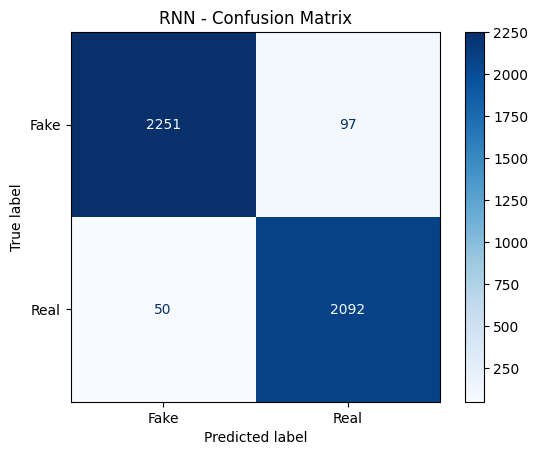

In [ ]:
evaluate_model('RNN',      y_test, rnn_preds)

              precision    recall  f1-score   support

        Fake       0.99      0.99      0.99      2348
        Real       0.99      0.99      0.99      2142

    accuracy                           0.99      4490
   macro avg       0.99      0.99      0.99      4490
weighted avg       0.99      0.99      0.99      4490



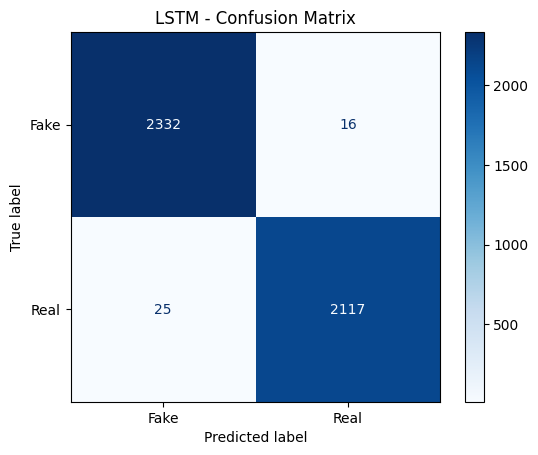

In [ ]:
evaluate_model('LSTM',     y_test, lstm_preds)


              precision    recall  f1-score   support

        Fake       1.00      1.00      1.00      2348
        Real       1.00      1.00      1.00      2142

    accuracy                           1.00      4490
   macro avg       1.00      1.00      1.00      4490
weighted avg       1.00      1.00      1.00      4490



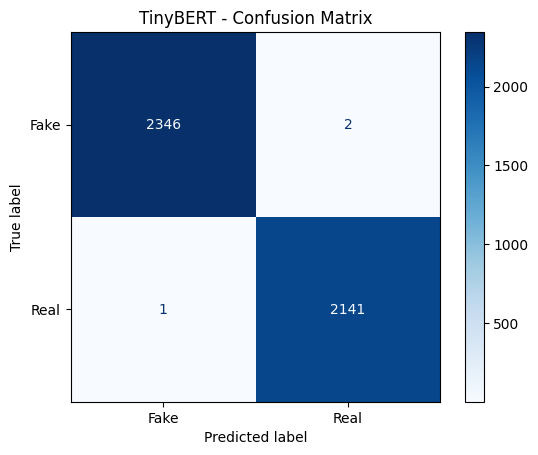

In [ ]:
evaluate_model('TinyBERT', y_test, tiny_bert_preds)

In [ ]:
# Overfitting Check
# A model is overfitting if the gap between train and val loss is large
# A small gap means the model generalizes well to unseen data
print("Overfitting Check")

# RNN
rnn_gap = abs(rnn_history.history['val_loss'][-1] - rnn_history.history['loss'][-1])
if rnn_gap > 0.1:
    rnn_verdict = 'Severe Overfitting'
elif rnn_gap > 0.05:
    rnn_verdict = 'Mild Overfitting'
else:
    rnn_verdict = 'Good Fit'
print(f"\nRNN:")
print(f"  Train Loss:    {rnn_history.history['loss'][-1]:.4f}")
print(f"  Val Loss:      {rnn_history.history['val_loss'][-1]:.4f}")
print(f"  Gap:           {rnn_gap:.4f} {rnn_verdict}")
print(f"  Test Accuracy: {accuracy_score(y_test, rnn_preds):.4f}")

# LSTM
lstm_gap = abs(lstm_history.history['val_loss'][-1] - lstm_history.history['loss'][-1])
if lstm_gap > 0.1:
    lstm_verdict = 'Severe Overfitting'
elif lstm_gap > 0.05:
    lstm_verdict = 'Mild Overfitting'
else:
    lstm_verdict = 'Good Fit'
print(f"\nLSTM:")
print(f"  Train Loss:    {lstm_history.history['loss'][-1]:.4f}")
print(f"  Val Loss:      {lstm_history.history['val_loss'][-1]:.4f}")
print(f"  Gap:           {lstm_gap:.4f} {lstm_verdict}")
print(f"  Test Accuracy: {accuracy_score(y_test, lstm_preds):.4f}")

# TinyBERT
tiny_bert_gap = abs(tiny_bert_val_loss[-1] - tiny_bert_train_loss[-1])
if tiny_bert_gap > 0.1:
    tiny_bert_verdict = 'Severe Overfitting'
elif tiny_bert_gap > 0.05:
    tiny_bert_verdict = 'Mild Overfitting'
else:
    tiny_bert_verdict = 'Good Fit'
print(f"\nTinyBERT:")
print(f"  Train Loss:    {tiny_bert_train_loss[-1]:.4f}")
print(f"  Val Loss:      {tiny_bert_val_loss[-1]:.4f}")
print(f"  Gap:           {tiny_bert_gap:.4f} {tiny_bert_verdict}")
print(f"  Test Accuracy: {accuracy_score(y_test, tiny_bert_preds):.4f}")

Overfitting Check

RNN:
  Train Loss:    0.0285
  Val Loss:      0.0953
  Gap:           0.0668 Mild Overfitting
  Test Accuracy: 0.9673

LSTM:
  Train Loss:    0.0085
  Val Loss:      0.0598
  Gap:           0.0514 Mild Overfitting
  Test Accuracy: 0.9909

TinyBERT:
  Train Loss:    0.0015
  Val Loss:      0.0048
  Gap:           0.0033 Good Fit
  Test Accuracy: 0.9993


Based on the difference bwteen the training and validation loss. the sequence based models show mild overfitting.

# Insights

- All three models performed extra ordinarly in the fake news detection dataset. There was a clear progression from the RNN to the LSTM then to TinyBERT.
- RNN achieved the lowest accuracy out of all the 3 models which was 96.73%. This was expected because of how RNN struggles with a long-range sequences which in news articles ic common. It also showed a mild overfitting with a gap os 0.0668 between training loss and validation loss.
- LSTM came in and impoved the accuracy to 99.09%, this was possible due to it gate structure which let it preserve crucial information through a long sequence. It also showed a mild overfittig with a gap of 0.0513 but it still generalized well on an unseen data.
- TinyBERT outperformed all the other models in this project. It got an accuracy of 99.93% with validation loss and training loss gap of 0.0033.
- It is worth noting that RNN and LSTM are trained from scratch, wheras TinyBERT has an obvious advantage as a pretrained model. Addinf dropour and early stopping made it possible to prevent sever overfitting for RNN and LSTM models.
- The perfromance gap overall shows how architectural superiority can and will affect the performance of a model. Performace is greatly impacted bu the architectural selection and the use of pretrained models, so from this compariosn we can learn that we must carefully chose a model depending on the work requirements and the goal we are trying to achieve.

AI Usage:

1. BERT tokenizer expects input. I continusly kept getting errors when using the pandaSeries that I had from the train_test_split for the other models. LLM proposed to use .tolist()
2. LLM used in plot the charts and confusion matrix.
3. LLM used in setting up trainer API based on HuggingFace documentation. Make some changes appropriate for my dataset.
4. LLM was used to create the overfitting check